# EDA con datos médicos & ML de arboles de decisión

* https://gemini.google.com/app/4b8a99c87f15c8b3?hl=es-ES

# **ML Random Forest**

Se utiliza para tareas de **clasificación** y **regresión**.

Es un tipo de aprendizaje que **ensamblan modelos** (model ensembling) para combinar las predicciones de múltiples árboles de decisión.

Cada árbol en un random forest se construye de manera independiente utilizando un **subconjunto aleatorio de los datos** de entrenamiento.

Luego, para hacer la predicción, cada árbol en el bosque hace su propia predicción y la **predicción final** se toma por **votación** de mayoría en el caso de clasificación, o **promedio** en el caso de regresión.

Este enfoque ayuda a superar el problema del sobreajuste, que es común con los árboles de decisión individuales.

## (0) **Imports**

> - split para modelado       
>         from sklearn.model_selection import train_test_split, GridSearchCV

Se puede usar en ese proyecto? Cómo? --> EN ARBOLES NO INFLUYE EL ESCALADO POR LE TIPO DE AGORITMO, YA QUE ELEGE . SI USADO EN KNN O REGRESION LINEAL
> - Scaled | Escalado:    
>         from sklearn.preprocessing import StandardScaler, MinMaxScaler
> - Encoding | Codificación:   
>         from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

> - To save models       
        import json  
        import pickle
> - Feature Selection: Se puede usar en ese proyecto?-> DUDA cómo?      
>        from sklearn.feature_selection import SelectKBest

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.preprocessing import StandardScaler, LabelEncoder # DUDA: seria útil usar label encoder?

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

## (1) **Lectura de los datos procesados**

In [10]:
df = pd.read_csv('../data/processed/diabetes_eda.csv')
pd.DataFrame(df)

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,10,101,76,32.9,0.171,63,0
764,2,122,70,36.8,0.340,27,0
765,5,121,72,26.2,0.245,30,0
766,1,126,60,30.1,0.349,47,1


* **Observación:** 

> Dado que el valor de glucosa es un gran determinante para en análisis y lo normal sería menos de 100 de glucosa en sangre, no filtro la columna para este modelo de aprendizaje para que el modelo aprenda a distinguir entre sanos y enfermos, es necesario mantener ambos grupos.


## (2) **Split**

In [ ]:
X = df.drop(['Outcome'], axis=1) 
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify=y para mantener la proporción de clases en el entrenamiento y testeo


> **NOTA:** los árboles de decisión y Random Forest no requieren escalado de datos, ya que se basan en particiones lógicas (si X > valor) y no en distancias.

## (3) **Construir el Modelo Random Forest** 

> - El random forest es un método de aprendizaje por ensamble (model ensembling) que combina las predicciones de múltiples árboles de decisión para generar una salida más precisa y robusta.  
> - Se utiliza RandomForestClassifier porque queremos clasificar el resultado en grupos, en este claso si el paciente tiene diabetes o no.  
> - **Replicabilidad: Es crucial establecer el hiperparámetro random_state** para asegurar que los resultados sean reproducibles en futuras ejecuciones

In [26]:
rf_classifier_model = RandomForestClassifier(random_state=18)
rf_classifier_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

> **Funcionamiento y boostrap aggregating**  
>  Cada árbol se construye de forma independiente usando un subconjunto aleatorio de datos (bagging o bootstrap aggregating) y un subconjunto aleatorio de características. La predicción final en clasificación se decide por votación de mayoría.  
>  Características:  
> - Entrenamiento inicial.  
> - Visualización: Puedes ver los árboles individuales.

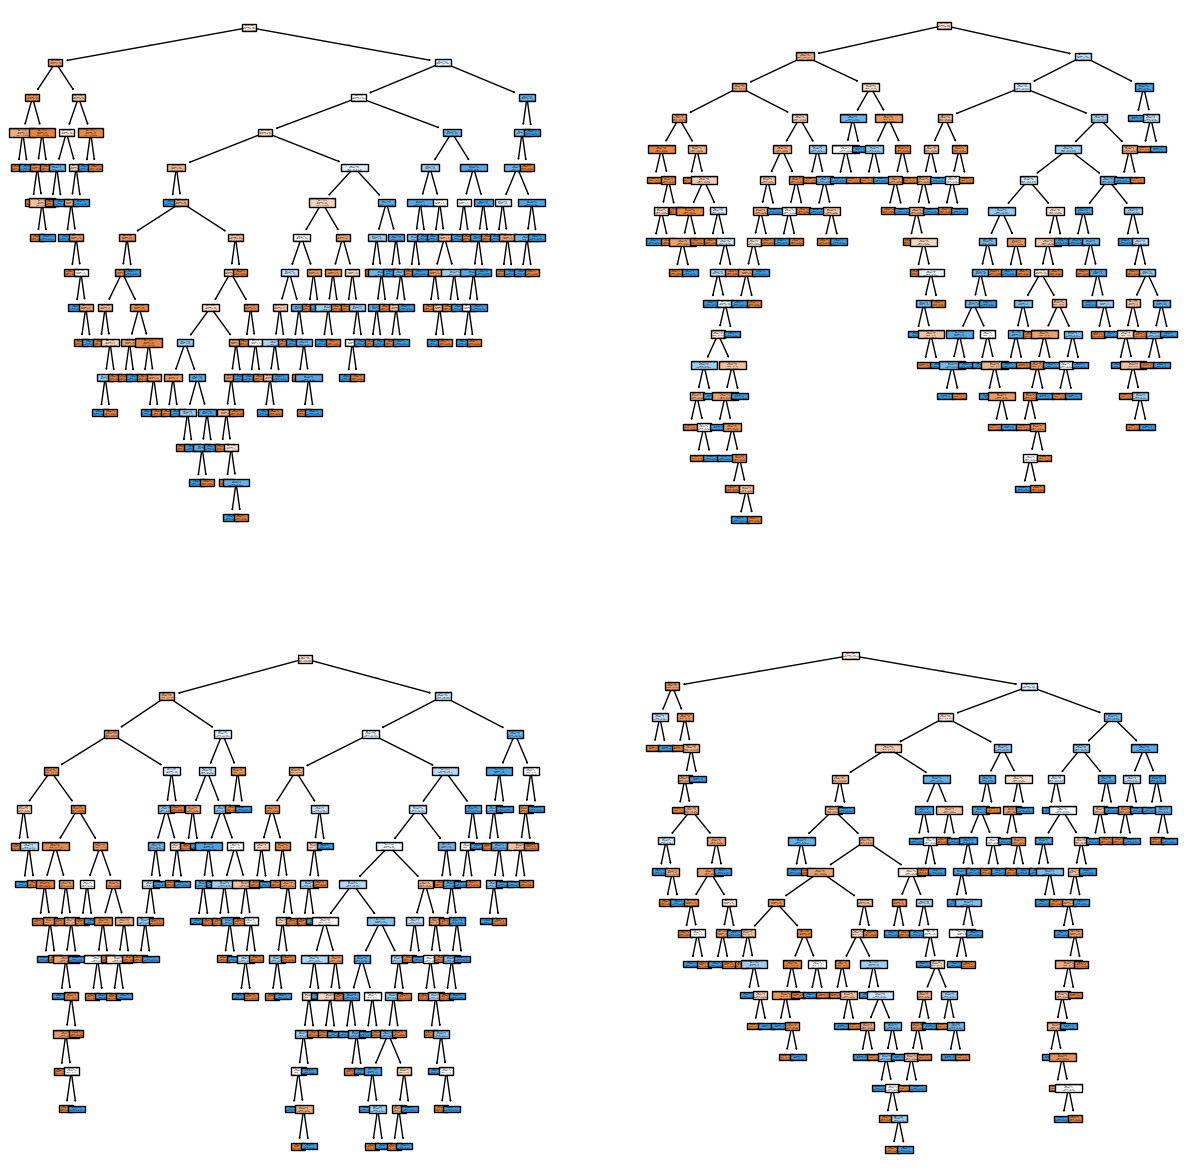

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(15, 15))

# Mostramos los 4 primeros árboles de los 100 generados (por defecto)
class_names = ["No Diabetes", "Diabetes"]
tree.plot_tree(rf_classifier_model.estimators_[0], ax=axis[0, 0],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf_classifier_model.estimators_[1], ax=axis[0, 1],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf_classifier_model.estimators_[2], ax=axis[1, 0],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf_classifier_model.estimators_[3], ax=axis[1, 1],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)

plt.show()

**Observaciones:**

*DUDA:CAMBAIR-REVISAR> * Cada nodo muestra una regla (por ejemplo Glucose > X) y su contribución para clasificar a las observaciones como 0 o 1:  
> Empieza dividiendo por Grupo1: BMI<= 26.75 y Grupo 2: BMI<=23.1.  
> Grupo 1 se subdivide en Pregnancies y Age  
> Grupo 2 analiza Diabetes Pedigree*

###  **Métricas del modelo de Clasificación** revisa - cambia


* **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy= accuracy_score(y_test, y_pred,normalize=False)
print("Accuracy Arbol:", accuracy)
* **Precision score**
print(precision_score(y_test, y_pred,average='micro'))
* **GridScearchCV: Overfitting**
https://4geeks.com/es/lesson/optimizacion-de-hiperparametros-del-modelo 
hyperparams = {'n_estimators': [50, 100, 200],'max_depth': [3, 5, 10],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

# Inicializamos la cuadrícula
grid = GridSearchCV(RandomForestClassifier(random_state=18),hyperparams,cv=5,n_jobs=-1,verbose=1)
print(grid)
* **Cassification report**
print(classification_report(y_test, y_pred)) # DUDA QUE SIGNIFCIAN LOS NUMEROS - INVESTIGAR Y ELEGIR UNA METRICA(ej:ACCURACY)
# probar una a una: precision, recall, ...


####  **Matriz de confusión**

DUDA::: Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado


In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))
confussion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');


**OBSERVACIONES:**

> Matriz de confusión: Esta matriz muestra cuántos valores se clasificaron correctamente o incorrectamente. Los valores diagonales representan aciertos y los otros representan errores.
DUDA--> CAMBIAR REPORTE


####  **Matriz de confusión para la predicción en base a la moda**

In [ ]:
matrix_moda = confusion_matrix(y_test, predicciones_mode)
print("Accuracy por clase:", matrix_moda.diagonal()/matrix_moda.sum(axis=1))
confussion_matrix_mode = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix_mode, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');


**OBSERVACIONES DE LAS MATRICES DE CONFUSIÓN:**

>Accuracy / Reporte de clasificación--- DUDA

> Este resultado es bueno o es malo?
> 
> Como saber si mi prediccion es buena o mala?
> 
> - 90% de Accuracy (u otra metrica) es bueno?
> - 30% de Accuracy (u otra metrica) es malo?
> 
> Todo es relativo, cual es el accuracy actual en el negocio? Que se utiliza actualmente para hacer la prediccion? Podemos comparar contra eso? Lo mejoramos o no?
> 
> Lo mas recomendado es establecer una base, si el negocio ya la tiene podemos empezar por alli si no podemos utilizar la media o la moda como predictor base dependiendo si la variable a predecir es numerica o categorica respectivamente.

####  **Moda como predictor base** DUDA: FUNCOINA EN ESTE ML?

Aqui utilizaremos los predictores Dummy de sklearn que nos permiten exactamente eso tener una base contra la cual comparar nuestros resultados


In [ ]:

# predictor_mode = DummyClassifier(strategy='most_frequent')
# predictor_mode.fit(X_train, y_train);

# predicciones_mode = predictor_mode.predict(X_test)

# accuracy_mode = accuracy_score(y_test, predicciones_mode)
# print("Accuracy base:", accuracy_mode)

####  **Matriz de confusión**

DUDA::: Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado

In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy por clase: [0.703125   0.84313725]


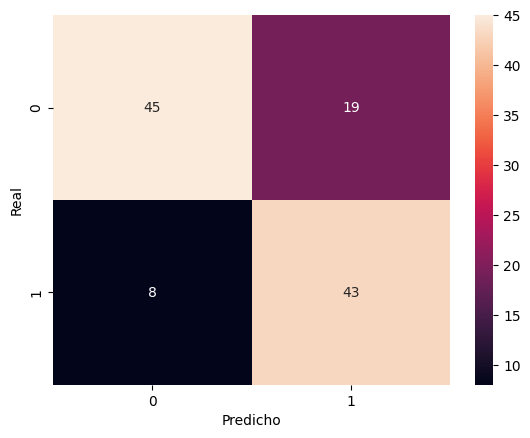

In [ ]:
confussion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

**OBSERVACIONES:**

> Matriz de confusión: Esta matriz muestra cuántos valores se clasificaron correctamente o incorrectamente. Los valores diagonales representan aciertos y los otros representan errores.
DUDA--> CAMBIAR REPORTE

In [ ]:
matrix_moda = confusion_matrix(y_test, predicciones_mode)
print("Accuracy por clase:", matrix_moda.diagonal()/matrix_moda.sum(axis=1))

Accuracy por clase: [1. 0.]


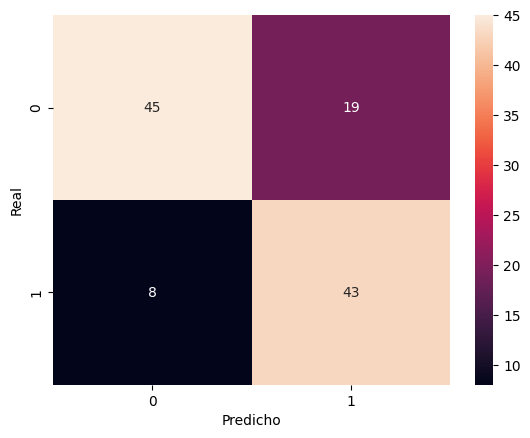

In [ ]:
confussion_matrix_mode = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix_mode, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

**OBSERVACIONES DE LAS MATRICES DE CONFUSIÓN:**

>Accuracy / Reporte de clasificación--- DUDA

> Este resultado es bueno o es malo?
> 
> Como saber si mi prediccion es buena o mala?
> 
> - 90% de Accuracy (u otra metrica) es bueno?
> - 30% de Accuracy (u otra metrica) es malo?
> 
> Todo es relativo, cual es el accuracy actual en el negocio? Que se utiliza actualmente para hacer la prediccion? Podemos comparar contra eso? Lo mejoramos o no?
> 
> Lo mas recomendado es establecer una base, si el negocio ya la tiene podemos empezar por alli si no podemos utilizar la media o la moda como predictor base dependiendo si la variable a predecir es numerica o categorica respectivamente.

* **Accuracy**

In [35]:
from sklearn.metrics import accuracy_score

accuracy= accuracy_score(y_test, y_pred,normalize=False)
print("Accuracy Arbol:", accuracy)

NameError: name 'y_pred' is not defined

* **Precision score**

In [ ]:
print(precision_score(y_test, y_pred,average='micro'))

0.7652173913043478


* **GridScearchCV: Overfitting**

https://4geeks.com/es/lesson/optimizacion-de-hiperparametros-del-modelo 

In [ ]:
hyperparams = {'n_estimators': [50, 100, 200],'max_depth': [3, 5, 10],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

# Inicializamos la cuadrícula
grid = GridSearchCV(RandomForestClassifier(random_state=18),hyperparams,cv=5,n_jobs=-1,verbose=1)
print(grid)

GridSearchCV(cv=5,
             estimator=     Pregnancies  Glucose  ...  Age  Outcome
0              6      148  ...   50        1
2              8      183  ...   32        1
4              0      137  ...   33        1
5              5      116  ...   30        0
7             10      115  ...   29        0
..           ...      ...  ...  ...      ...
761            9      170  ...   43        1
763           10      101  ...   63        0
764            2      122  ...   27        0
765            5      121  ...   30        0
766            1      126  ...   47        1

[571 rows x 7 columns],
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')


* **Cassification report**

In [ ]:
print(classification_report(y_test, y_pred)) # DUDA QUE SIGNIFCIAN LOS NUMEROS - INVESTIGAR Y ELEGIR UNA METRICA(ej:ACCURACY)
# probar una a una: precision, recall, ...

              precision    recall  f1-score   support

           0       0.85      0.70      0.77        64
           1       0.69      0.84      0.76        51

    accuracy                           0.77       115
   macro avg       0.77      0.77      0.77       115
weighted avg       0.78      0.77      0.77       115



## (4) **Predicción**

###  **DataFrame comparativo entre las predicciones y la data de testeo**

* Usamos X_test para predecir
* Análisis Overfitting con x_train vs X_test

In [28]:
y_pred_test = rf_classifier_model.predict(X_test)
y_pred_test

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1])

In [29]:
len(y_pred_test)

115

In [30]:
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test
pred_vs_real["predicciones"] = y_pred_test
pred_vs_real

,y_test,predicciones
114,1,1
142,0,0
511,0,0
175,1,1
339,1,1
...,...,...
138,0,0
752,0,0
470,0,0
267,0,1


In [31]:
y_pred_train = rf_classifier_model.predict(X_train)
y_pred_train

array([1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,

In [32]:
len(y_pred_train)

456

Es importante considerar que este dataset es un problema de clasificación multiclase con tres clases (setosa, versicolor y virginica).

Al evaluar algunas metricas en un escenario multiclase, hay varias formas de promediar los resultados, siendo las más comunes "micro", "macro" y "weighted".

- Micro Average:
    - Es útil cuando las clases tienen un tamaño similar y cuando quieres tener en cuenta todas las instancias por igual.
    - Si aciertas 90/100 flores en total (sin importar la clase), el micro-avg es 0.90.
- Macro Average
    - Es adecuado cuando se quiere evaluar el rendimiento del modelo en cada clase de forma independiente y las clases son igualmente importantes.
    - Si la precisión es 0.90 (setosa), 0.80 (versicolor) y 0.70 (virginica), el macro-avg es (0.9 + 0.8 + 0.7) / 3 = 0.80.
- Weighted Average
    - Es ideal cuando las clases están desequilibradas y se quiere tener en cuenta el tamaño de cada clase en la evaluación global.
    - Similar al macro, pero cada precisión se multiplica por el número de muestras de esa clase antes de promediar.

## (5) **Optimización de hiperparametros**

> **Optimización de Hiperparámetros: Para mejorar el accuracy**, debes ajustar los parámetros que definen el bosque y los árboles individuales:
> - n_estimators: Es el número de árboles. Un número mayor suele aumentar la precisión y estabilidad, aunque incrementa el tiempo de cálculo.
> - max_depth: Controla la profundidad máxima de los árboles; es decir, cuántas divisiones puede hacer.
> - min_samples_split y min_samples_leaf: Controlan el número mínimo de muestras para dividir un nodo o para que exista una hoja, lo cual ayuda a prevenir el sobreajuste (overfitting).
> - max_features: Define el número máximo de características a considerar en cada división> - 

* **Definición de hiperparámetros para GridSearchCV**

In [ ]:
hparam_diabetes = {'n_estimators': [28],'max_depth': [8, 21, 29],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

* **Implementación de GridSearchCV:**

In [ ]:
grid_diabetes = GridSearchCV(RandomForestClassifier(random_state=18),hparam_diabetes,cv=5,n_jobs=-1,verbose=1)


* **Entrenamos en modelo con GridSearchCV:**

In [ ]:
grid_diabetes.fit(X_train, y_train)
grid_diabetes.best_params_


## (6) **Guardado del Modelo**

In [ ]:
with open('../../models/diabetes-random-forest.pkl', 'wb') as file:
    pickle.dump(grid_diabetes.best_estimator_, file)